# Road Hazard Detection: Milestone 1 Baseline
This notebook establishes a baseline model using HOG features and an RBF SVM classifier to distinguish between potholes and road debris.

**Pipeline:** iCrawler (Web Scraping) → Preprocessing → HOG → SVM → Evaluation

In [166]:
# CELL 2 — Clear old data (run once at the start)
shutil.rmtree('data/pothole_on_road', ignore_errors=True)
shutil.rmtree('data/road_debris', ignore_errors=True)
print("Cleared. Now re-upload your images.")

Cleared. Now re-upload your images.


In [167]:
# CELL 1 — Imports
import os
import shutil
import time
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import joblib
from google.colab import files as colab_files
from skimage.feature import hog
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)

## Step 1: Data Collection — iCrawler


In [168]:
# iCrawler Web Scraping
!pip install -q icrawler
from icrawler.builtin import BingImageCrawler

def scrape_images(class_name, keywords, count_per_keyword=100):
 # esm el folder , list of keywoards, images to dowloand per key word
    save_dir = f'data/{class_name}' #folder path
    os.makedirs(save_dir, exist_ok=True) # if its already exist leave it.
    for kw in keywords: #loops gowa kol keyword
        print(f'Scraping: {kw}...')
        crawler = BingImageCrawler(storage={'root_dir': save_dir}, downloader_threads=4)
        crawler.crawl(keyword=kw, max_num=count_per_keyword) # runs actual search
        time.sleep(2)
    total = len(os.listdir(save_dir))
    print(f'{class_name}: {total} images collected')

p_kw = [
    'pothole' , 'pothole street'
]

d_kw = [
     'debris street' , 'debris road'
]

scrape_images('pothole_on_road', p_kw)
scrape_images('road_debris', d_kw)

Scraping: pothole...


ERROR:downloader:Response status code 403, file https://www.prwlaw.com/wp-content/uploads/2022/09/How-do-potholes-cause-accidents.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/065/273/702/large_2x/pothole-filled-with-water-on-cracked-asphalt-road-surface-closeup-photo.jpg


Scraping: pothole street...
pothole_on_road: 31 images collected
Scraping: debris street...
Scraping: debris road...
road_debris: 32 images collected


## Step 2: Data Ingestion — Manual Upload
Due to search engine noise, scraped images are supplemented with manually curated road hazard images to ensure dataset quality.

In [169]:
# CELL 4 — Manual Upload
#def handle_upload(category): # takes an input
  #  path = f'data/{category}'
   # os.makedirs(path, exist_ok=True) # creates a folder if it does not exist
    #print(f'Uploading for: {category}')
    #uploaded = colab_files.upload() # opens the file picker to select el hagat el dowloaded
    #for filename, content in uploaded.items():
      #  with open(os.path.join(path, filename), 'wb') as f: #n runs images as binary
       #     f.write(content)
    #print(f'Done! {len(uploaded)} images saved to {path}') # 3shan a3rf kam haga ba2ya

#handle_upload('pothole_on_road')    handle_upload('road_debris')

## Step 3: Dataset Validation
Verify all collected images are readable before feature extraction.

In [170]:
# CELL 5
for cat in ['pothole_on_road', 'road_debris']:
    folder_path = f'data/{cat}'# builds folder path
    all_files = glob.glob(f'{folder_path}/*') # finds every file inside that folder
    valid_count = 0
    for f in all_files:
        img = cv2.imread(f) # tries to read the image in cv
        if img is not None:
            valid_count += 1
    print(f'{cat}: {valid_count} valid images out of {len(all_files)} total files.')
    if valid_count == 0:
        print(f'!! WARNING: No valid images found in {cat}.')

pothole_on_road: 31 valid images out of 31 total files.
road_debris: 32 valid images out of 32 total files.


## Step 4: Preprocessing & HOG Feature Extraction
Each image is:
1. Converted to grayscale
2. Enhanced with CLAHE (histogram equalization)
3. Resized to 128×128
4. Passed through HOG feature extraction → 1,764-dimensional feature vector

In [171]:
# CELL 6 — Preprocessing & HOG Feature Extraction
def extract_features(directory, target_size=(128, 128)):
    features = [] #stores hog feuature
    labels = [] #str clkass label
    label_map = {'pothole_on_road': 0, 'road_debris': 1}
    cat_name = os.path.basename(directory)

    file_list = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp', '*.avif']:
        file_list.extend(glob.glob(os.path.join(directory, ext))) # make sure all images extraction is true


    print(f'Processing {len(file_list)} images for {cat_name}...')
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for f in file_list:
        img = cv2.imread(f)
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = clahe.apply(gray)             # CLAHE (const. limited adaptive histogram equalization ) histogram equalization
        resized = cv2.resize(gray, target_size) # resize to 128 * 128
        fd = hog(resized, orientations=9, # msre grad in 9 direc
                 pixels_per_cell=(16, 16),
                 cells_per_block=(2, 2),  # grouping
                 visualize=False,
                 block_norm='L2-Hys')
        features.append(fd) #add image features
        labels.append(label_map[cat_name])
    return features, labels

p_feat, p_lab = extract_features('data/pothole_on_road')
d_feat, d_lab = extract_features('data/road_debris')

X = np.array(p_feat + d_feat)
y = np.array(p_lab + d_lab)
print(f'Feature matrix shape: {X.shape}')
print(f'Feature vector size per image: {X.shape[1]} dimensions')

Processing 31 images for pothole_on_road...
Processing 32 images for road_debris...
Feature matrix shape: (63, 1764)
Feature vector size per image: 1764 dimensions


## Step 5: HOG Feature Visualization
Visualizing what HOG sees — gradient patterns that distinguish potholes from debris.

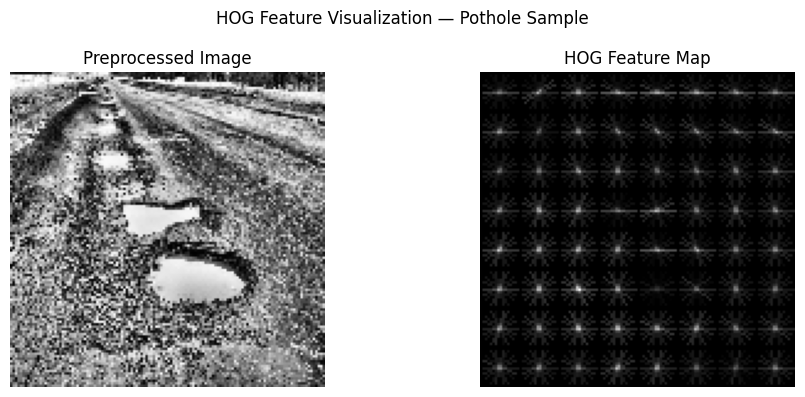

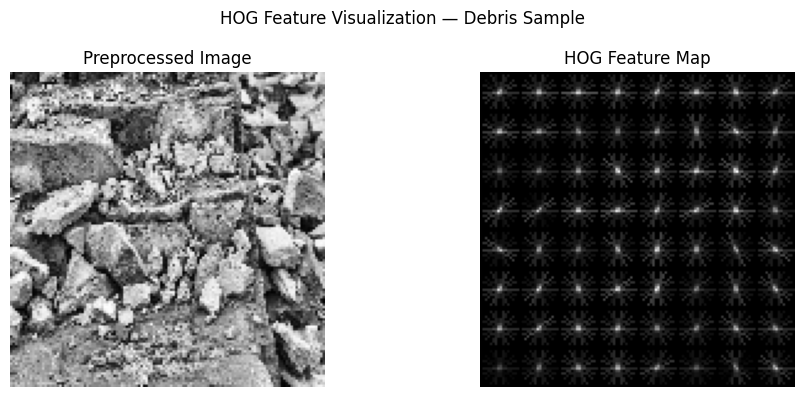

In [172]:
#HOG Visualization
sample_path = glob.glob('data/pothole_on_road/*.jpg')
if sample_path:
    sample_img = cv2.imread(sample_path[0])
    gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY) #converts to grey
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray) #contrast
    resized = cv2.resize(gray, (128, 128))
    fd, hog_image = hog(resized, orientations=9, pixels_per_cell=(16, 16),
                        cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(resized, cmap='gray')
    ax1.set_title('Preprocessed Image')
    ax1.axis('off')
    ax2.imshow(hog_image, cmap='gray')
    ax2.set_title('HOG Feature Map')
    ax2.axis('off')
    plt.suptitle('HOG Feature Visualization — Pothole Sample')
    plt.tight_layout()
    plt.show()

# Debris sample
debris_path = glob.glob('data/road_debris/*.jpg')
if debris_path:
    debris_img = cv2.imread(debris_path[0])
    gray_d = cv2.cvtColor(debris_img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_d = clahe.apply(gray_d)
    resized_d = cv2.resize(gray_d, (128, 128))
    fd_d, hog_image_d = hog(resized_d, orientations=9, pixels_per_cell=(16, 16),
                        cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(resized_d, cmap='gray')
    ax1.set_title('Preprocessed Image')
    ax1.axis('off')
    ax2.imshow(hog_image_d, cmap='gray')
    ax2.set_title('HOG Feature Map')
    ax2.axis('off')
    plt.suptitle('HOG Feature Visualization — Debris Sample')
    plt.tight_layout()
    plt.show()


## Step 6: SVM Training & Evaluation
Pipeline: HOG Features → StandardScaler → SVM (RBF kernel) → Prediction

Test Accuracy:  84.62%

Classification Repot:
              precision    recall  f1-score   support

     Pothole       0.75      1.00      0.86         6
      Debris       1.00      0.71      0.83         7

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13

ROC-AUC:        0.9524
CV F1 (5-fold): 0.7727 ± 0.0379


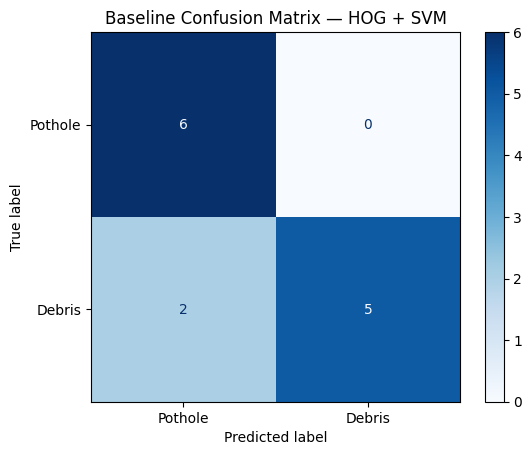

In [173]:
# CELL 8 — Model Training & Evaluation

# 1. Train/Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # learns the deviaition of training
X_test = scaler.transform(X_test)

# 3. Train SVM
clf = svm.SVC(kernel='rbf', C=1.0, probability=True)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test) # runs the modeel on test images
print(f'Test Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\nClassification Repot:')
print(classification_report(y_test, y_pred, target_names=['Pothole', 'Debris']))

# 5. ROC-AUC
roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f'ROC-AUC:        {roc_auc:.4f}')
#predict_proba(X_test) — returns confidence scores for both classes for each image.
#roc_auc_score — measures how well the model separates the two classes.
# 6. CV F1 (5-fold)
cv_f1 = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_weighted')
print(f'CV F1 (5-fold): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pothole', 'Debris'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix — HOG + SVM')
plt.show()

## Step 7: Save Model
Saving the trained SVM, scaler, and HOG configuration for future inference.

In [174]:
# CELL 9 — Save Model
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(clf, os.path.join(model_dir, 'roadguard_svm_baseline.pkl'))
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))

hog_config = {
    'orientations': 9,
    'pixels_per_cell': (16, 16),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'target_size': (128, 128)
}
joblib.dump(hog_config, os.path.join(model_dir, 'hog_config.pkl'))

print('Milestone 1 finalized!')
print('  Model   → models/roadguard_svm_baseline.pkl')
print('  Scaler  → models/scaler.pkl')
print('  HOG cfg → models/hog_config.pkl')

Milestone 1 finalized!
  Model   → models/roadguard_svm_baseline.pkl
  Scaler  → models/scaler.pkl
  HOG cfg → models/hog_config.pkl


In [176]:
import shutil
shutil.make_archive('roadguard_submission', 'zip', '.', 'models')
from google.colab import files
files.download('roadguard_submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>